In [1]:
import torch 
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")
import glob
from collections import OrderedDict  
from ReportPretraining import ReportClassification
from src.layers.transformer.ATAT import LightCurveTransformer

from src.utils.data.AlerceDictionaries import ELASTICC_TAXONOMY, ZTF_TAXONOMY
import matplotlib.pyplot as plt
import numpy as np

In [2]:
DATASET  ='test'
DEVICE = 'cuda:0'
PATH_1 = '/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/results/200/LC/class_baseline_0/'
PATH_2 = '/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/results/200/LC/class_test_v1/'


#FP_DATASET = "/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/data/datasets/ZTF_ff/final/LC_MD_FEAT_240627_windows_200_12/dataset.h5"

FP_DATASET ='/home/mdelafuente/ZTF_SSL_Dataset/data/H5_files/BY_PARTITION/200_FF.h5'

Found checkpoint 2736.ckpt
Found checkpoint 2736.ckpt
Loaded backbone weights
LOaded classifier weights
using sampler
class_sampler_count [1783 1804 1785 1526 1566 1008 1855 1440  872  891 1858 1860 1814 1876
  763  973  278  121   56   70  172   17]
not using sampler
class_sampler_count [443 477 495 422 375 271 455 338 210 206 453 458 449 450 198 242  66  25
   9  14  38   3]
device set to cuda:0


100%|██████████| 477/477 [00:07<00:00, 63.12it/s]


                precision    recall  f1-score   support

           AGN     0.4371    0.2626    0.3281       556
           QSO     0.6054    0.7105    0.6538       570
            EA     0.7786    0.7649    0.7717       570
           YSO     0.5316    0.4497    0.4872       487
          SNIa     0.7134    0.4825    0.5756       485
       CV/Nova     0.5915    0.5656    0.5783       320
          RRLc     0.7173    0.7111    0.7142       578
         RSCVn     0.4964    0.4595    0.4772       444
        Blazar     0.3417    0.4556    0.3905       270
          SNII     0.5672    0.2774    0.3725       274
         EB/EW     0.7181    0.6920    0.7048       578
           LPV     0.8468    0.8103    0.8282       580
           CEP     0.6062    0.5495    0.5765       566
         RRLab     0.7643    0.7577    0.7610       582
Periodic-Other     0.3413    0.4750    0.3972       240
          DSCT     0.4698    0.6908    0.5593       304
         SNIbc     0.2024    0.3953    0.2677  

<Axes: title={'center': 'ZTF ATAT LC ONLY: test | macro f1: 0.451'}, xlabel='Predicted label', ylabel='True label'>

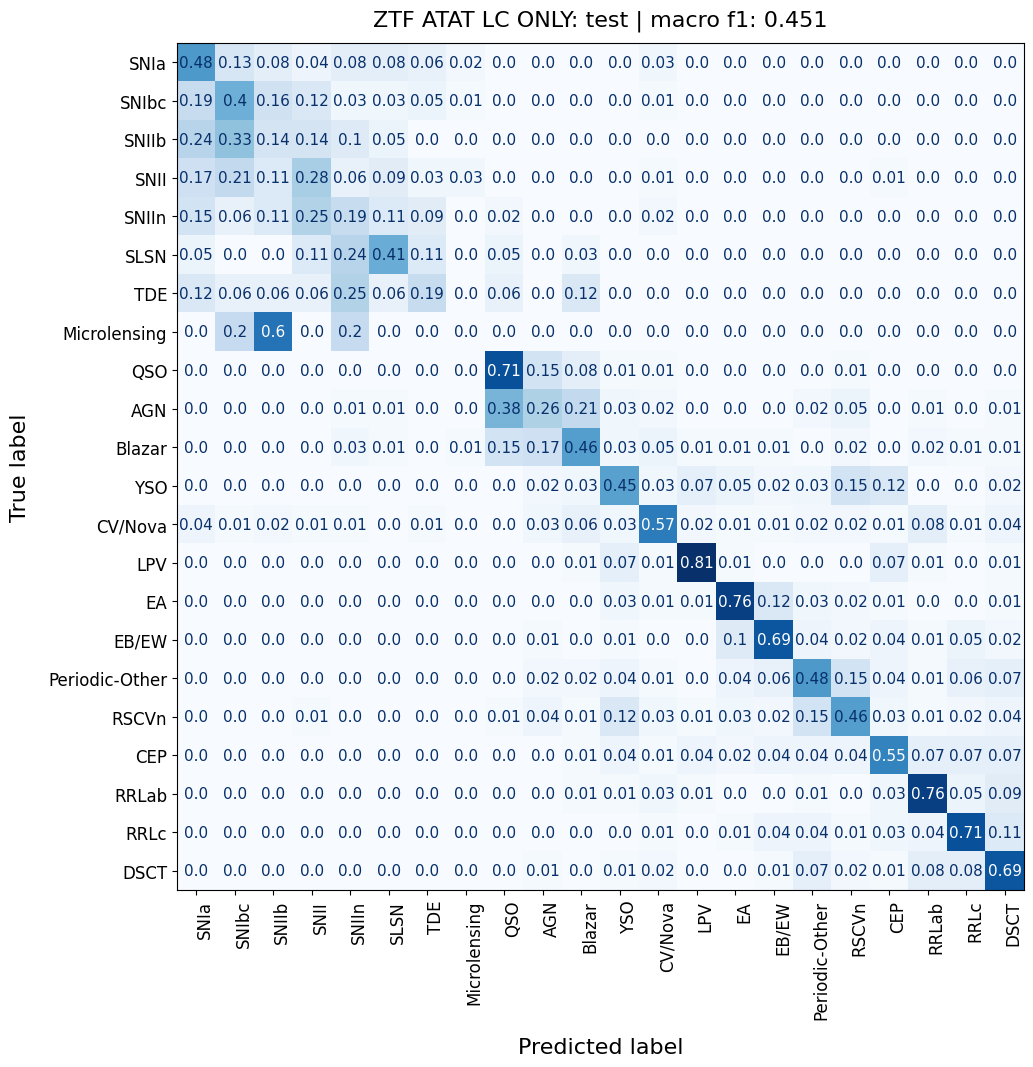

In [8]:
from src.exploringtools.InitBackbone import InitBackbone
from src.exploringtools.InitClassifier import InitClassifier, ztf_order_classes
from src.exploringtools.InitDataloader import InitDataLoader
from src.layers.classifiers.MultimodalClassifier import MultimodalClassifier
from src.layers.classifiers.HierClassifiery import Hier


test = InitClassifier(path_to_config_yaml=PATH_1, 
                    model= LightCurveTransformer, 
                    classifier = MultimodalClassifier,
                    use_lc = True,
                    arg_key='lc')
backbone_od = test.create_ordered_dict(remove_if_in_key_list=['projection', 'transformer_tab', 'classifier'],rename_keys = ('model.',''), checkpoint_name='classifier_ckpt')
classifier_od = test.create_ordered_dict(remove_if_in_key_list=['projection', 'model',],rename_keys = ('classifier.',''), checkpoint_name='classifier_ckpt')
test.load_backbone_weights(backbone_od)
test.load_classifier_weights(classifier_od)
test.args.datamodule.val_use_sampler = False

dl = InitDataLoader(update_dataset_path=FP_DATASET,update_batch_size=16,datamodule_args=test.args.datamodule)
from sklearn.metrics import classification_report
val_preds, val_true =test.predict(dl.test_dataset, DEVICE) if DATASET == 'test' else test.predict(dl.validation_dataset, DEVICE)
report_1 = classification_report(val_true, np.argmax(val_preds, axis = -1), target_names=list(ZTF_TAXONOMY().keys()),digits = 4, output_dict=True)
print(classification_report(val_true, np.argmax(val_preds, axis = -1), target_names=list(ZTF_TAXONOMY().keys()),digits = 4, output_dict=False))
test.get_confusion_matrix(np.argmax(val_preds, axis = -1), val_true, dataset_type=DATASET, taxonomy = ZTF_TAXONOMY, plot_title= 'ZTF ATAT LC ONLY', order_classes=ztf_order_classes)


PATH = '/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/results/200/MD/class_baseline/'

Found checkpoint 1392.ckpt
Found checkpoint 1392.ckpt
Loaded backbone weights
LOaded classifier weights
using sampler
class_sampler_count [1783 1804 1785 1526 1566 1008 1855 1440  872  891 1858 1860 1814 1876
  763  973  278  121   56   70  172   17]
not using sampler
class_sampler_count [443 477 495 422 375 271 455 338 210 206 453 458 449 450 198 242  66  25
   9  14  38   3]
device set to cuda:0


100%|██████████| 382/382 [00:04<00:00, 85.52it/s] 


<Axes: title={'center': 'ZTF ATAT LC ONLY: test | macro f1: 0.4474'}, xlabel='Predicted label', ylabel='True label'>

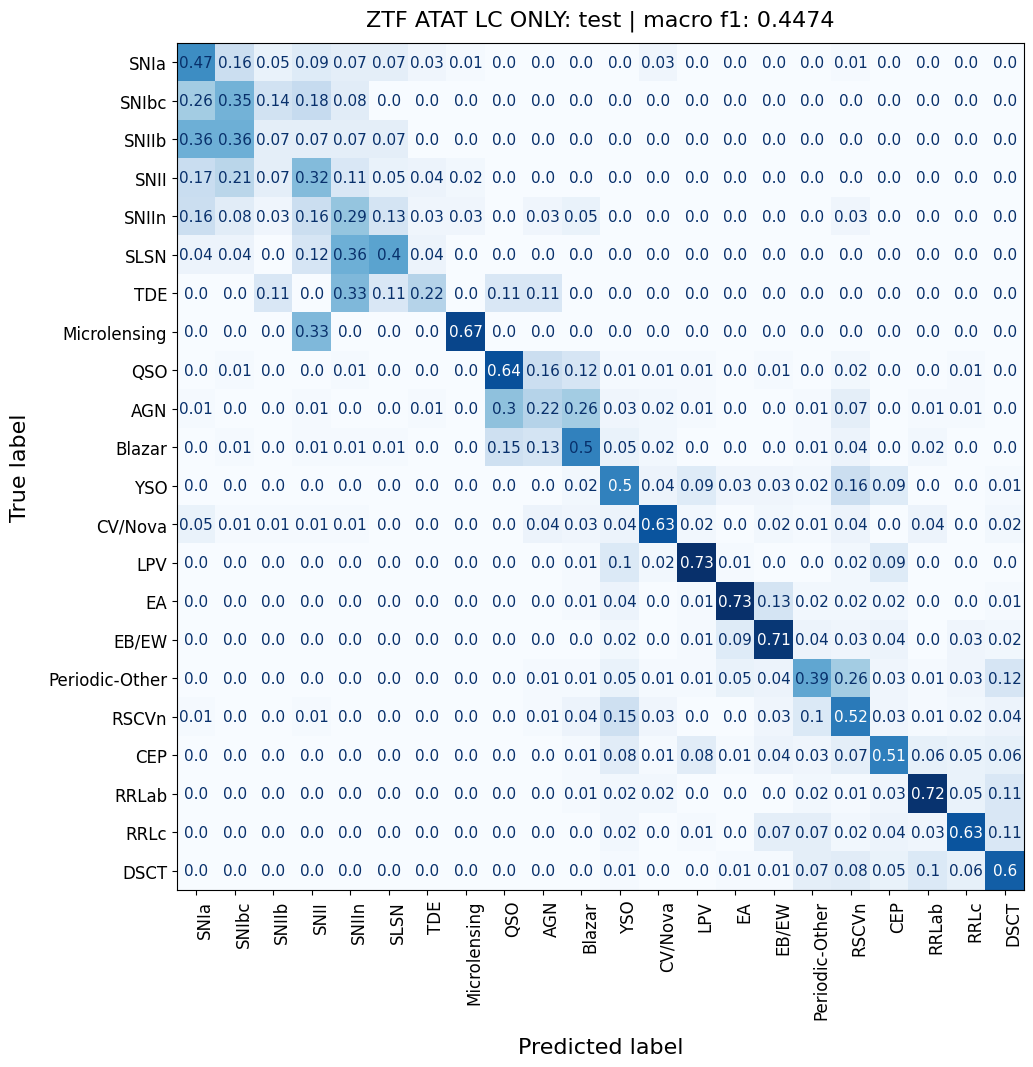

In [20]:
from src.exploringtools.InitBackbone import InitBackbone
from src.exploringtools.InitClassifier import InitClassifier
from src.exploringtools.InitDataloader import InitDataLoader
from src.layers.classifiers.MultimodalClassifier import MultimodalClassifier
from src.layers.classifiers.HierClassifiery import Hier
test = InitClassifier(path_to_config_yaml=PATH_2, 
                    model= LightCurveTransformer, 
                    classifier = MultimodalClassifier,
                    use_lc = True,
                    arg_key='lc')

backbone_od = test.create_ordered_dict(remove_if_in_key_list=['projection', 'transformer_tab', 'classifier'],rename_keys = ('model.',''), checkpoint_name='classifier_ckpt')
classifier_od = test.create_ordered_dict(remove_if_in_key_list=['projection', 'model',],rename_keys = ('classifier.',''), checkpoint_name='classifier_ckpt')
test.load_backbone_weights(backbone_od)
test.load_classifier_weights(classifier_od)
test.args.datamodule.val_use_sampler = False

dl = InitDataLoader(update_dataset_path=FP_DATASET,update_batch_size=16,datamodule_args=test.args.datamodule)
from sklearn.metrics import classification_report
val_preds, val_true =test.predict(dl.validation_dataset, DEVICE)
report_2 = classification_report(val_true, np.argmax(val_preds, axis = -1), target_names=list(ZTF_TAXONOMY().keys()),digits = 4, output_dict=True)
test.get_confusion_matrix(np.argmax(val_preds, axis = -1), val_true, dataset_type=DATASET, taxonomy = ZTF_TAXONOMY, plot_title= 'ZTF ATAT LC ONLY', order_classes=ztf_order_classes)

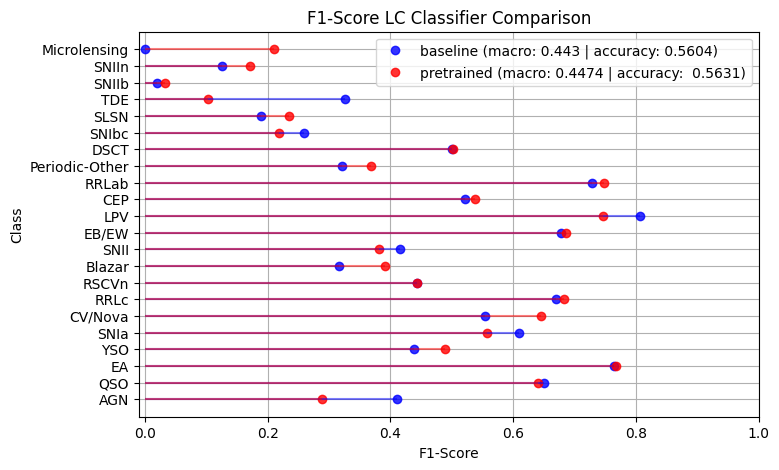

baseline f1 mean:
trans 0.24308296752556813
stoch 0.47384036028506654
per 0.6036393135024084
pretrained f1 mean:
trans 0.24087948827879951
stoch 0.4822313823768322
per 0.6062592117512359


In [21]:
import pandas as pd
import numpy as np

def compare_models(d1,d2, eval_time= 2048):

    f1_baseline = []
    f1_finetune = []

    fig,ax = plt.subplots(1,1,figsize = (8,5))
    for key,value in d1.items():
       # print(key,value)
        if key in ZTF_TAXONOMY().keys():
        
            f1_baseline.append(value['f1-score'])
        
    df_1 = pd.DataFrame({'group':ZTF_TAXONOMY().keys(), 'values':f1_baseline })
    ordered_df_1 = df_1 #.sort_values(by='values')
    my_range_1=range(1,len(df_1.index)+1)

    for key,value in d2.items():
        if key in (ZTF_TAXONOMY().keys()):
            #print(key,value)
            f1_finetune.append(value['f1-score'])
    df_2 = pd.DataFrame({'group':ZTF_TAXONOMY().keys(), 'values':f1_finetune})
    ordered_df_2 = df_2 #.sort_values(by='values')
    my_range_2=range(1,len(df_2.index)+1)
    plt.plot(ordered_df_1['values'].values, my_range_1, "o", alpha = 0.8,color='blue')
    plt.plot(ordered_df_2['values'].values, my_range_2, "o", alpha = 0.8,color='red')

    plt.legend(['1','2'])
    
    # The horizontal plot is made using the hline function
    plt.hlines(y=my_range_1, xmin=0, xmax=ordered_df_1['values'], color='blue', alpha = 0.5)
    
    # The horizontal plot is made using the hline function
    plt.hlines(y=my_range_2, xmin=0, xmax=ordered_df_2['values'], color='red', alpha = 0.5)

    # Add titles and axis names
    plt.yticks(my_range_1, ordered_df_1['group'])
    plt.title(f"F1-Score LC Classifier Comparison", loc='center')

    plt.xlabel('F1-Score')
    plt.ylabel('Class')
    plt.xlim(-0.01,1)
    #plt.xticks(np.arange(0,1,50), ordered_df_1['group'])
    plt.grid('on', )

    plt.legend([f'baseline (macro: {np.round(d1['macro avg']['f1-score'],4)} | accuracy: {np.round(d1['accuracy'],4)})',
                f'pretrained (macro: {np.round(d2['macro avg']['f1-score'],4)} | accuracy:  {np.round(d2['accuracy'],4)})'])
    # Show the plot
    plt.show()
compare_models(report_1,report_2)

transient =  {
    "SNIa": 4,
    "SNII": 9,
    "SNIbc": 16,
    "SLSN": 17,
    "TDE": 18,
    "SNIIb": 19,
    "SNIIn": 20,
    "Microlensing": 21
}

stochastic =  {
    "AGN": 0,
    "QSO": 1,
    "YSO": 3,
    "CV/Nova": 5,
    "Blazar": 8,
}

periodic =  {
    "EA": 2,
    "RRLc": 6,
    "RSCVn": 7,
    "EB/EW": 10,
    "LPV": 11,
    "CEP": 12,
    "RRLab": 13,
    "Periodic-Other": 14,
    "DSCT": 15,
}
import numpy as np
trans_f1 = []
stoch_f1 = []
per_f1 = []
for class_key, value in report_1.items():
    #print(class_key)
    if class_key in ZTF_TAXONOMY().keys():
        
        if class_key in transient.keys():
            trans_f1.append(value['f1-score'])
        if class_key in stochastic.keys():
            stoch_f1.append(value['f1-score'])
        if class_key in periodic.keys():
            per_f1.append(value['f1-score'])
print('baseline f1 mean:')
print('trans',np.mean(trans_f1))
print('stoch',np.mean(stoch_f1))
print('per',np.mean(per_f1))
for class_key, value in report_2.items():
    #print(class_key)
    if class_key in ZTF_TAXONOMY().keys():
        
        if class_key in transient.keys():
            trans_f1.append(value['f1-score'])
        if class_key in stochastic.keys():
            stoch_f1.append(value['f1-score'])
        if class_key in periodic.keys():
            per_f1.append(value['f1-score'])
print('pretrained f1 mean:')
print('trans',np.mean(trans_f1))
print('stoch',np.mean(stoch_f1))
print('per',np.mean(per_f1))

In [ ]:
asdfas

NameError: name 'asdfas' is not defined

In [ ]:
from ReportPretraining import InitDataLoader, InitClassifier
from src.layers.classifiers.MultimodalClassifier import MultimodalClassifier
from src.layers.transformer.ATAT import TabularTransformer

test = InitClassifier(path_to_config_yaml=PATH_2, 
                    model= TabularTransformer, 
                    classifier = MultimodalClassifier,
                    use_lc = False,
                    use_tab = True,
                    arg_key='tab')
backbone_od = test.create_ordered_dict(remove_if_in_key_list=['projection', 'transformer_lc', 'classifier'],rename_keys = ('model.',''), checkpoint_name='classifier_ckpt')
classifier_od = test.create_ordered_dict(remove_if_in_key_list=['projection', 'model',],rename_keys = ('classifier.',''), checkpoint_name='classifier_ckpt')
test.load_backbone_weights(backbone_od)
test.load_classifier_weights(classifier_od)
dl = InitDataLoader(update_dataset_path=FP_DATASET,update_batch_size=32,datamodule_args=test.args.datamodule)
from sklearn.metrics import classification_report
val_preds, val_true =test.predict(dl.validation_dataset, DEVICE)
print(classification_report(val_true, np.argmax(val_preds, axis = -1), target_names=list(ZTF_TAXONOMY().keys()),digits = 4, output_dict=False))
test.get_confusion_matrix(np.argmax(val_preds, axis = -1), val_true, dataset_type='validation', taxonomy = ZTF_TAXONOMY)


ImportError: cannot import name 'InitDataLoader' from 'ReportPretraining' (/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/ReportPretraining.py)

{'experiment_type': 'LC_MD', 'experiment_name': 'lc_ckpt', 'lc': {'input_size': 1, 'embedding_size': 192, 'embedding_size_sub': 384, 'num_heads': 4, 'num_encoders': 3, 'Tmax': 2000.0, 'pe_type': 'tm', 'num_harmonics': 4, 'num_bands': 2, 'dropout': 0.1, 'checkpoint': '/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/results/200/LC/final_v0/', 'freeze_weights': False}, 'tab': {'embedding_size': 128, 'embedding_size_sub': 256, 'num_heads': 4, 'num_encoders': 3, 'length_size': 6, 'dropout': 0.1, 'checkpoint': None, 'freeze_weights': False}, 'datamodule': {'dataset': {'data_root': '/home/mdelafuente/ZTF_SSL_Dataset/data/H5_files/BY_PARTITION/200_FF.h5', 'experiment_type': 'LC_MD', 'seed': 0, 'train_apply_transform': True, 'validation_apply_transform': False, 'train_key': 'training', 'validation_key': 'validation', 'test_key': 'test', 'observation_key': 'flux', 'observation_err_key': 'flux_err', 'time_key': 'time', 'time_alert_key': 'time_alert', 'mask_key': 'mask',

/home/mdelafuente/miniconda3/envs/ATAT/lib/python3.12/site-packages/torch/nn/modules/transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/ReportPretraining.py:531: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_g

Found checkpoint 144.ckpt
Loaded backbone weights
Loaded backbone weights
Found checkpoint 144.ckpt
Loaded backbone weights
0
using sampler
class_sampler_count [1765 1852 1813 1529 1558 1012 1869 1393  868  904 1856 1860 1831 1869
  763  977  277  107   52   63  155   15]
0
not using sampler
class_sampler_count [461 429 467 419 383 267 441 385 214 193 455 458 432 457 198 238  67  39
  13  21  55   5]
0
device set to cuda:0
Combinator(
  (transformer_lc): LightCurveTransformer(
    (time_encoder): TimeHandler(
      (time_encoders): ModuleList(
        (0-1): 2 x TimeFilmModified(
          (linear_proj): Sequential(
            (0): Linear(in_features=1, out_features=192, bias=True)
          )
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (dropout): Dropout(p=0.1, inplace=False)
    (transformer_lc): TransformerEncoder(
      (layers): ModuleList(
        (0-2): 3 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_pr

100%|██████████| 191/191 [00:05<00:00, 37.82it/s]


                precision    recall  f1-score   support

           AGN     0.7845    0.7028    0.7414       461
           QSO     0.6826    0.8671    0.7639       429
            EA     0.7980    0.5246    0.6331       467
           YSO     0.6840    0.5012    0.5785       419
          SNIa     0.7385    0.3760    0.4983       383
       CV/Nova     0.6552    0.4981    0.5660       267
          RRLc     0.5380    0.5782    0.5574       441
         RSCVn     0.6354    0.6156    0.6253       385
        Blazar     0.5632    0.4579    0.5052       214
          SNII     0.5094    0.2798    0.3612       193
         EB/EW     0.6019    0.5582    0.5792       455
           LPV     0.8374    0.7533    0.7931       458
           CEP     0.5000    0.6042    0.5472       432
         RRLab     0.6279    0.6018    0.6145       457
Periodic-Other     0.3450    0.4495    0.3904       198
          DSCT     0.3363    0.6387    0.4406       238
         SNIbc     0.2154    0.2090    0.2121  

<Axes: title={'center': 'ATAT dataset zero shot logit reg: validation | macro f1: 0.4682'}, xlabel='Predicted label', ylabel='True label'>

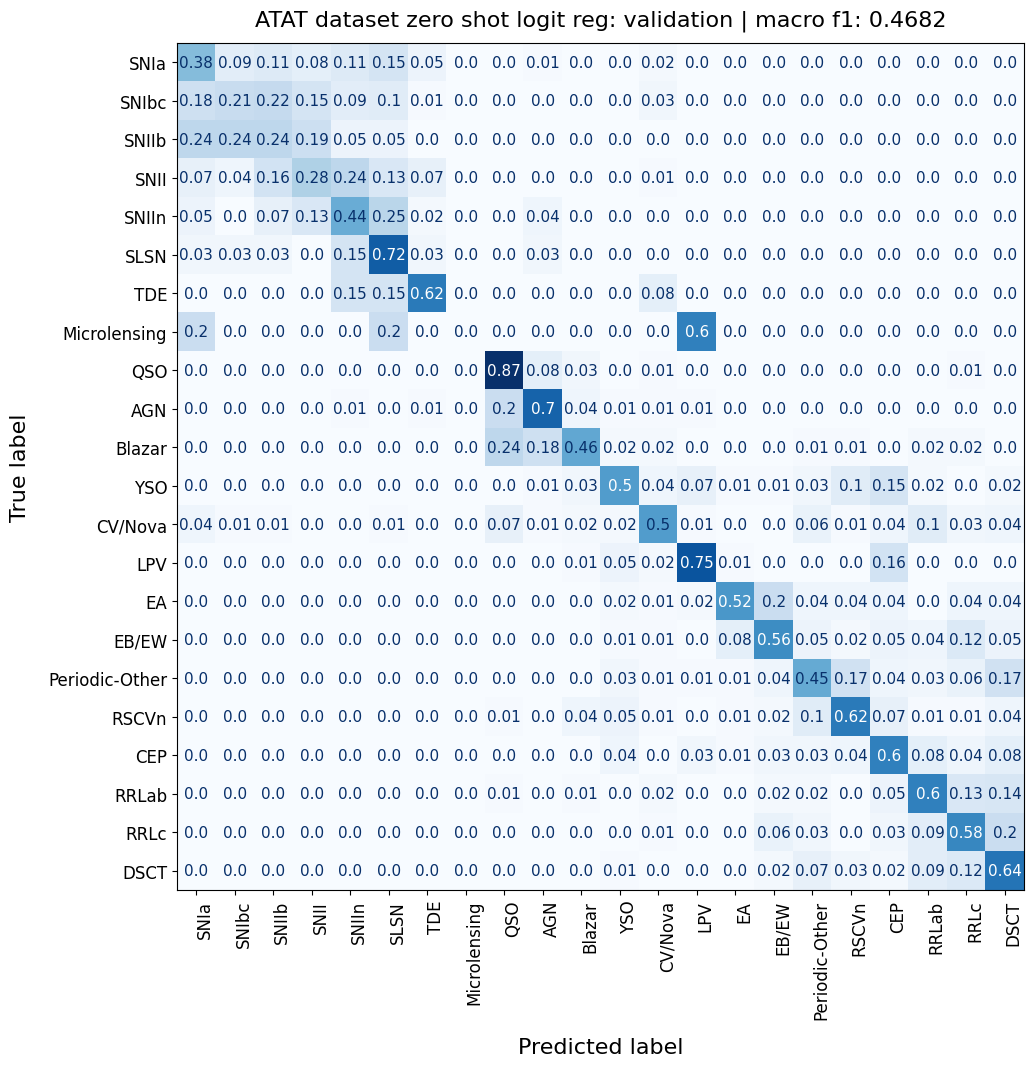

In [ ]:
from ReportPretraining import InitBackbone,InitCombinator, InitDataLoader
from src.layers.classifiers.MultimodalClassifier import MultimodalClassifier
from src.layers.transformer.ATAT import TabularTransformer, Combinator, LightCurveTransformer
import numpy as np
from src.utils.data.AlerceDictionaries import ELASTICC_TAXONOMY, ZTF_TAXONOMY


PATH = '/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/results/200/LC_MD/lc_ckpt/'
FP_DATASET ='/home/mdelafuente/ZTF_SSL_Dataset/data/H5_files/BY_PARTITION/200_FF.h5'
DEVICE = 'cuda:0'
test = InitCombinator(path_to_config_yaml=PATH, 
                    lc_model= LightCurveTransformer, 
                    tab_model= TabularTransformer, 
                    classifier = MultimodalClassifier,
                    arg_key='tab', 
                    device = DEVICE)
dl = InitDataLoader(update_dataset_path=FP_DATASET,update_batch_size=32,datamodule_args=test.args.datamodule)
from sklearn.metrics import classification_report
val_preds, val_true =test.predict(dl.validation_dataset, DEVICE)
print(classification_report(val_true, np.argmax(val_preds, axis = -1), target_names=list(ZTF_TAXONOMY().keys()),digits = 4, output_dict=False))
test.get_confusion_matrix(np.argmax(val_preds, axis = -1), val_true, dataset_type='validation', taxonomy = ZTF_TAXONOMY)


In [ ]:
adsfadf

In [ ]:
import pandas as pd
import numpy as np

def compare_models(d1,d2, eval_time= 2048):

    f1_baseline = []
    f1_finetune = []

    fig,ax = plt.subplots(1,1,figsize = (8,5))
    for key,value in d1.items():
        print(key,value)
        if key in ZTF_TAXONOMY().keys():
        
            f1_baseline.append(value['f1-score'])
        
    df_1 = pd.DataFrame({'group':ZTF_TAXONOMY().keys(), 'values':f1_baseline })
    ordered_df_1 = df_1 #.sort_values(by='values')
    my_range_1=range(1,len(df_1.index)+1)

    for key,value in d2.items():
        if key in (ZTF_TAXONOMY().keys()):
            #print(key,value)
            f1_finetune.append(value['f1-score'])
    df_2 = pd.DataFrame({'group':ZTF_TAXONOMY().keys(), 'values':f1_finetune})
    ordered_df_2 = df_2 #.sort_values(by='values')
    my_range_2=range(1,len(df_2.index)+1)
    plt.plot(ordered_df_1['values'].values, my_range_1, "o", alpha = 0.8,color='blue')
    plt.plot(ordered_df_2['values'].values, my_range_2, "o", alpha = 0.8,color='red')

    plt.legend(['1','2'])
    
    # The horizontal plot is made using the hline function
    plt.hlines(y=my_range_1, xmin=0, xmax=ordered_df_1['values'], color='blue', alpha = 0.5)
    
    # The horizontal plot is made using the hline function
    plt.hlines(y=my_range_2, xmin=0, xmax=ordered_df_2['values'], color='red', alpha = 0.5)

    # Add titles and axis names
    plt.yticks(my_range_1, ordered_df_1['group'])
    plt.title(f"F1-Score LC Classifier Comparison", loc='center')

    plt.xlabel('F1-Score')
    plt.ylabel('Class')
    plt.xlim(-0.01,1)
    #plt.xticks(np.arange(0,1,50), ordered_df_1['group'])
    plt.grid('on', )

    plt.legend([f'baseline (macro: {np.round(d1['macro avg']['f1-score'],4)} | accuracy: {np.round(d1['accuracy'],4)})',
                f'pretrained (macro: {np.round(d2['macro avg']['f1-score'],4)} | accuracy:  {np.round(d2['accuracy'],4)})'])
    # Show the plot
    plt.show()
compare_models(report1,report2)

transient =  {
    "SNIa": 4,
    "SNII": 9,
    "SNIbc": 16,
    "SLSN": 17,
    "TDE": 18,
    "SNIIb": 19,
    "SNIIn": 20,
    "Microlensing": 21
}

stochastic =  {
    "AGN": 0,
    "QSO": 1,
    "YSO": 3,
    "CV/Nova": 5,
    "Blazar": 8,
}

periodic =  {
    "EA": 2,
    "RRLc": 6,
    "RSCVn": 7,
    "EB/EW": 10,
    "LPV": 11,
    "CEP": 12,
    "RRLab": 13,
    "Periodic-Other": 14,
    "DSCT": 15,
}
import numpy as np
trans_f1 = []
stoch_f1 = []
per_f1 = []
for class_key, value in report1.items():
    #print(class_key)
    if class_key in ZTF_TAXONOMY().keys():
        
        if class_key in transient.keys():
            trans_f1.append(value['f1-score'])
        if class_key in stochastic.keys():
            stoch_f1.append(value['f1-score'])
        if class_key in periodic.keys():
            per_f1.append(value['f1-score'])
print('baseline f1 mean:')
print('trans',np.mean(trans_f1))
print('stoch',np.mean(stoch_f1))
print('per',np.mean(per_f1))
for class_key, value in report2.items():
    #print(class_key)
    if class_key in ZTF_TAXONOMY().keys():
        
        if class_key in transient.keys():
            trans_f1.append(value['f1-score'])
        if class_key in stochastic.keys():
            stoch_f1.append(value['f1-score'])
        if class_key in periodic.keys():
            per_f1.append(value['f1-score'])
print('pretrained f1 mean:')
print('trans',np.mean(trans_f1))
print('stoch',np.mean(stoch_f1))
print('per',np.mean(per_f1))

NameError: name 'ljlkj' is not defined

In [ ]:
'''
import numpy as np
import pandas as pd
probs, target = test_1.predict_probs()

review = pd.DataFrame({'is_correct':abs(np.argmax(probs, axis = -1) - target)  == 0,'target':target })
display(review)
def subset_df(subset):

    print(len(subset))

    import h5py
    with h5py.File('data/datasets/ZTF_ff/final/LC_MD_FEAT_240627_windows_200_12/dataset.h5', 'r') as f:
        flux_incorrect  = f.get('flux')[subset]
        target_incorrect = f.get('labels')[subset]
    print(flux_incorrect.shape)
    dict_ = {value:key for key, value in ZTF_TAXONOMY().items()}
    df = pd.DataFrame({'obs_count':np.count_nonzero(flux_incorrect, axis = (1,2)), 'target':target_incorrect.astype(int)})
    df['target'] = df['target'].map(dict_)
    df = df.groupby('target').aggregate({'obs_count':list})
    df['incorrect_count'] =  df.obs_count.apply(lambda x: len(x))#.reset_index()
    df['mean'] = df['obs_count'].apply(lambda x: np.mean(x).round(2))
    df['std'] = df['obs_count'].apply(lambda x: np.std(x).round(2))
    df = df.sort_values('incorrect_count', ascending = False)
    return df

subset_df(subset = review.query('is_correct == False').index.tolist())
subset_df(subset = review.query('is_correct == True').index.tolist())
'''

In [ ]:

def plot_f1(data_dict, taxonomy):

    f1 = []
    for key,value in data_dict.items():
        if key in taxonomy().keys():
            print(key,value)
            f1.append(value['f1-score'])
    print(f1)

    import pandas as pd
    import matplotlib.pyplot as plt
    import numpy as np
    
    # Create a dataframe
    df = pd.DataFrame({'group':taxonomy().keys(), 'values':f1 })
    
    # Reorder it based on the values
    ordered_df = df#.sort_values(by='values')
    my_range=range(1,len(df.index)+1)
    
    # The horizontal plot is made using the hline function
    plt.hlines(y=my_range, xmin=0, xmax=ordered_df['values'], color='skyblue')
    plt.plot(ordered_df['values'].values, my_range, "o")
    
    # Add titles and axis names
    plt.yticks(my_range, ordered_df['group'])
    plt.title("F1-Score For Each Class", loc='center')

    plt.xlabel('F1-Score')
    plt.ylabel('Class')
    plt.xlim(0,1)

    plt.grid('on')
    # Show the plot
    plt.show()

In [ ]:

trans_f1 = []
stoch_f1 = []
per_f1 = []
for class_key, value in report_2.items():
    #print(class_key)
    if class_key in ZTF_TAXONOMY().keys():
        
        if class_key in transient.keys():
            trans_f1.append(value['f1-score'])
        if class_key in stochastic.keys():
            stoch_f1.append(value['f1-score'])
        if class_key in periodic.keys():
            per_f1.append(value['f1-score'])
print('group eval:')    
print('trans',np.mean(trans_f1))
print('stoch',np.mean(stoch_f1))
print('per',np.mean(per_f1))

In [ ]:
adfadf

In [ ]:
def early_as(path_1:str, before_time:int,supress_cm = False,supress_dict = False):
    path_args = glob.glob(f"{path_1}*args*")[0]
    #print(path_args)
    with open(path_args, 'r') as file:
        args = yaml.safe_load(file)
    #print('Initializing models') 
    model = LightCurveClassifier(**args) 
    #print('Loading checkpoints')
    checkpoint_path_clip = glob.glob(
        f"{path_1}*my_best_checkpoint*"
    ) 
    #print(checkpoint_path_clip[-1])
    checkpoint_clip = torch.load(checkpoint_path_clip[-1], map_location=torch.device(DEVICE))
    od_atat = OrderedDict() 
    for key in checkpoint_clip["state_dict"].keys(): 
            #print(key)
            if 'project' in key:
                continue
            if 'model' in key:
                od_atat[key.replace("model.", "")] = checkpoint_clip["state_dict"][key]

    model.load_state_dict(od_atat,strict=True)
    args['general']['data_root'] = 'data/datasets/ZTF_ff/final/LC_MD_FEAT_240627_windows_200_12'
    args['general']['use_sampler'] = False
    args['general']['batch_size'] = 256

    pl_datal = LitData(**args['general'])
    dataloader = pl_datal.test_dataloader() 
    target = None
    preds_out = None

    model.eval().to(device = DEVICE)  

    for b1 in tqdm(dataloader):

        #print(b1.keys())
        b1 = {key:value.to(device = DEVICE) for key, value in b1.items()}
        #print(b1['time'].shape,b1['mask'].shape)
        #b1['data'][:,before_time:,:] = 0
        #b1['time'][:,before_time:,:] = 0
        #b1['mask'] = (b1['data'] !=0)
        mask = torch.ones_like(b1['mask'])
        #mask[before_time:,:] = 0 
        #b1['mask'] = b1['mask'] * mask
        lc_emb = model(**b1)  
        t = b1['labels']
        preds_out = (
            np.concatenate([preds_out, torch.argmax(lc_emb, axis=1).detach().cpu().numpy()])
            if preds_out is not None
            else torch.argmax(lc_emb, axis=1).cpu().detach().numpy()
        )
        target = (
            np.concatenate([target, t.cpu().detach().numpy()])
            if target is not None
            else t.detach().cpu().numpy()
        )
    results = preds_out
    classification = classification_report(target, results, target_names=list(DICT.keys()),digits = 4)
    data_dict =  classification_report(target, results, target_names=list(DICT.keys()),digits = 4, output_dict=True)    
    if supress_dict == 0:
        print(classification)
    if supress_cm == 0:        
        from src.utils.plottinglib import elasticc_confusion_matrix
        out_metrics_balto = classification_report(
            target, results, target_names=list(DICT.keys()), output_dict=True
        )["macro avg"]
        template_balto = ""
        for key in out_metrics_balto.keys():
            template_balto += " {} : {:.3f} ".format(key.upper(), out_metrics_balto[key])
        fig, axes = plt.subplots(1, 1, figsize=(12, 12))
        elasticc_confusion_matrix(
            y_true=np.array(target).astype(int),
            y_pred=np.array(results).astype(int),
            classes= np.array(list(DICT.keys())),
            ax=axes,
            normalize=True,
            
            title=f" FClassifier Results [TEST] \n\n {template_balto}",
        )
        plt.show()
    
    return data_dict

In [ ]:
data_dict_1['macro avg']['f1-score']

In [ ]:
e_times = [10,20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170,180,200]
macro_f1_eval_times = {'d1':[],'d2':[]}
for eval_time in e_times:
    data_dict_1 = early_as(path_1, before_time = eval_time,supress_cm=True,supress_dict=True)
    data_dict_2 = early_as(path_2, before_time = eval_time,supress_cm=True,supress_dict=True)
    macro_f1_eval_times['d1'].append(data_dict_1['macro avg']['f1-score'])
    macro_f1_eval_times['d2'].append(data_dict_2['macro avg']['f1-score'])
    compare_models(data_dict_1,data_dict_2,eval_time)

data_dict_1 = produce_report(path_1)
data_dict_2 = produce_report(path_2) 

In [ ]:
import seaborn as sns

sns.lineplot(macro_f1_eval_times[::-1])
#plt.legend(['baseline','pretrained'])

plt.title('F1-score for ')
plt.xticks(list(range(len(e_times))),[str(time) for time in e_times])
plt.xlabel('Max Evaluated Time')
plt.ylabel('F1-score')
plt.grid('on')

modl is not sample dependent